In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Settings
pd.set_option('display.max_columns',None)   #To display all the columns of the dataset no matter how many columns may present.
sns.set(style='whitegrid')                  #To display grids in graphs
import warnings                             #To ignore the filter warnings
warnings.filterwarnings('ignore')

In [2]:
#Load data
df = pd.read_excel(r"World_development_mesurement.xlsx")

#Gets the first 5 column rows
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,NaN,0.034,0.0,0.100,71.0,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,NaN,0.128,0.0,1.032,47.0,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,NaN,0.090,0.0,NaN,57.0,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,NaN,0.054,0.0,0.155,52.0,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,NaN,0.096,0.0,NaN,52.0,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
# Shape of data
df.shape

(2704, 25)

In [4]:
#Column names
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [5]:
print('---------------------Data Info-----------------------------------')
print(df.info())

print('---------------------Null values---------------------------------')
print(df.isnull().sum())

print('-------------------Duplicated Rows------------------------------->>>',df.duplicated().sum())

---------------------Data Info-----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        188

In [6]:
print('---Data Description---')
df.describe().T

---Data Description---


,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.0,2.271489e-02,1.133843e-02,0.007,0.01300,2.000000e-02,3.100000e-02,5.300000e-02
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000,1360.00000,8.529000e+03,5.910800e+04,8.286892e+06
Days to Start Business,1718.0,3.999942e+01,5.731859e+01,1.000,13.00000,2.600000e+01,4.500000e+01,6.940000e+02
Ease of Business,185.0,9.487568e+01,5.479191e+01,1.000,48.00000,9.400000e+01,1.420000e+02,1.890000e+02
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000,3737.00000,1.433800e+04,4.185200e+04,2.727728e+06
Health Exp % GDP,2395.0,6.416952e-02,2.632460e-02,0.008,0.04600,6.100000e-02,7.900000e-02,2.250000e-01
Hours to do Tax,1416.0,3.020685e+02,2.732997e+02,12.000,156.00000,2.390000e+02,3.447500e+02,2.600000e+03
Infant Mortality Rate,2444.0,3.281301e-02,2.996760e-02,0.002,0.00900,2.000000e-02,5.300000e-02,1.410000e-01
Internet Usage,2531.0,2.397471e-01,2.601318e-01,0.000,0.00000,1.000000e-01,4.000000e-01,1.000000e+00
Lending Interest,1880.0,1.481027e-01,1.718291e-01,0.005,0.08000,1.200000e-01,1.730000e-01,4.965000e+00


### Data Cleaning

In [7]:
#Checking number unqiue values in each column
df.nunique()

Birth Rate                  47
Business Tax Rate          447
CO2 Emissions             1743
Country                    208
Days to Start Business     126
Ease of Business           185
Energy Usage              1721
GDP                       2494
Health Exp % GDP           145
Health Exp/Capita         1069
Hours to do Tax            280
Infant Mortality Rate      129
Internet Usage              11
Lending Interest           351
Life Expectancy Female      49
Life Expectancy Male        47
Mobile Phone Usage          26
Number of Records            1
Population 0-14            376
Population 15-64           298
Population 65+             208
Population Total          2699
Population Urban           822
Tourism Inbound           1650
Tourism Outbound          1457
dtype: int64

In [8]:
#Checking the mixed char in number before converting to numeric datatype
print(df['GDP'].unique())
print(df['Business Tax Rate'].unique()[:10])
print(df['Health Exp/Capita'].unique())

['$54,790,058,957' '$9,129,594,819' '$2,359,122,303' ...
 '$16,244,600,000,000' '$50,004,354,667' '$381,286,223,859']
[nan '76.9%' '52.1%' '75.7%' '17.1%' '47.5%' '279.7%' '50.6%' '65.7%'
 '74.0%']
['$60' '$22' '$15' ... '$972' '$8,895' '$1,308']


In [9]:
#Removing mixed char in numbers
cols=['Business Tax Rate','GDP','Health Exp/Capita','Tourism Inbound','Tourism Outbound']
for col in cols:
    df[col]=(
        df[col]
        .astype(str)
        .str.replace('$','',regex=False)
        .str.replace('%','',regex=False)
        .str.replace(',','',regex=False)
        .str.strip()
    )

In [10]:
#Converting data type from object to numeric
for col in cols:
    df[col]=pd.to_numeric(df[col], errors='coerce')

In [11]:
missing_percentage=(df.isnull().sum()/len(df))*100
missed_values=pd.DataFrame({
    'Missing_count':df.isnull().sum(),
    'Missing_percentage':missing_percentage
})
threshold=50
missing_sort=missed_values.sort_values(by='Missing_percentage',ascending=False)
print(missing_sort[missing_sort['Missing_percentage']>threshold])

                  Missing_count  Missing_percentage
Ease of Business           2519           93.158284


In [12]:
# Droping High missing values column  Ease of Business ->2519/2704
col='Ease of Business'
df.drop(col,axis=1,inplace=True)

In [13]:
#Number unique values each column
df.nunique()

Birth Rate                  47
Business Tax Rate          447
CO2 Emissions             1743
Country                    208
Days to Start Business     126
Energy Usage              1721
GDP                       2494
Health Exp % GDP           145
Health Exp/Capita         1069
Hours to do Tax            280
Infant Mortality Rate      129
Internet Usage              11
Lending Interest           351
Life Expectancy Female      49
Life Expectancy Male        47
Mobile Phone Usage          26
Number of Records            1
Population 0-14            376
Population 15-64           298
Population 65+             208
Population Total          2699
Population Urban           822
Tourism Inbound           1650
Tourism Outbound          1457
dtype: int64

In [14]:
# Number of records column have only single values which are not relavence for model development
#so we are droping column Number of Records
df.drop('Number of Records',axis=1,inplace=True)

In [15]:
#Filling missing values with median
num_col=df.select_dtypes(include='number').columns
df[num_col]=df[num_col].fillna(df[num_col].median())

In [16]:
#Drop duplicates
df.drop_duplicates(inplace=True)

In [17]:
#Re-checking the Datatype
print(df.dtypes)

#Re-check null values 
print('_____Null_values_____')
print(df.isnull().sum())

Birth Rate                float64
Business Tax Rate         float64
CO2 Emissions             float64
Country                    object
Days to Start Business    float64
Energy Usage              float64
GDP                       float64
Health Exp % GDP          float64
Health Exp/Capita         float64
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total            int64
Population Urban          float64
Tourism Inbound           float64
Tourism Outbound          float64
dtype: object
_____Null_values_____
Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP           

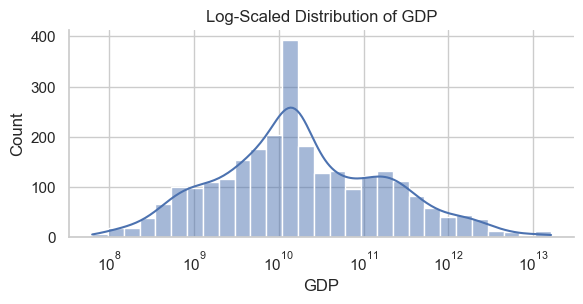

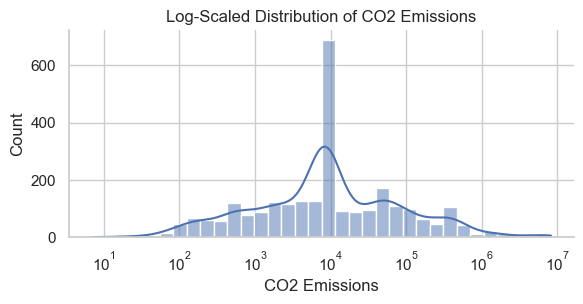

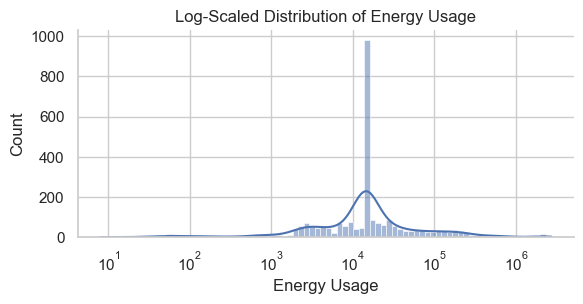

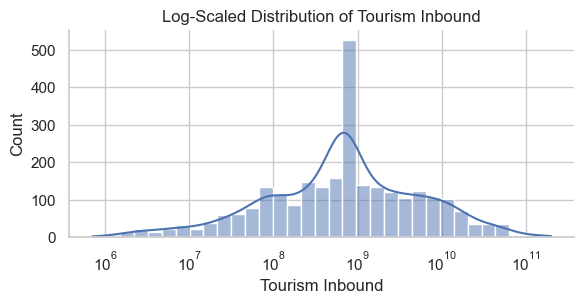

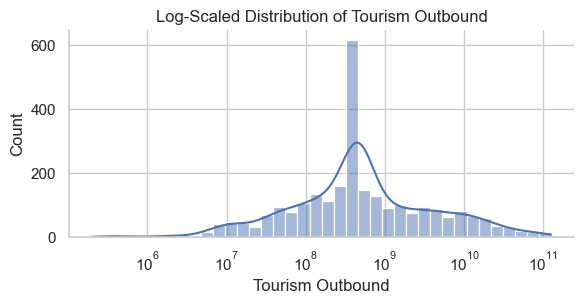

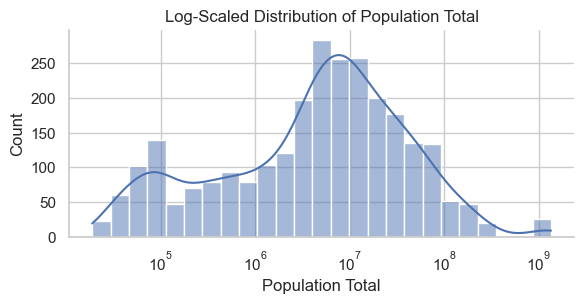

In [18]:
#Big_cols columns are highly right skewed and have extreme outliers 
#Univariate Analysis
# Use log_scale=True inside the plot only. 
# This makes the graph readable without changing the underlying 'df' data yet.
big_cols = ['GDP','CO2 Emissions','Energy Usage', 
            'Tourism Inbound','Tourism Outbound','Population Total']

for col in big_cols:
    sns.displot(data=df, x=col, kde=True, kind='hist', log_scale=True, height=3, aspect=2)
    plt.title(f"Log-Scaled Distribution of {col}")
    plt.show()


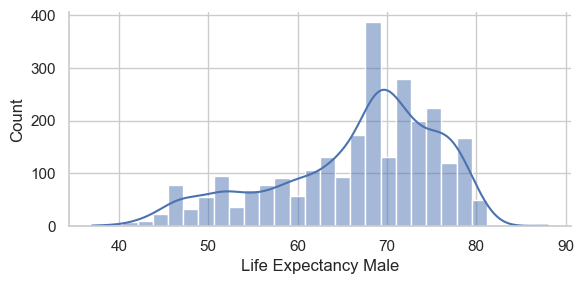

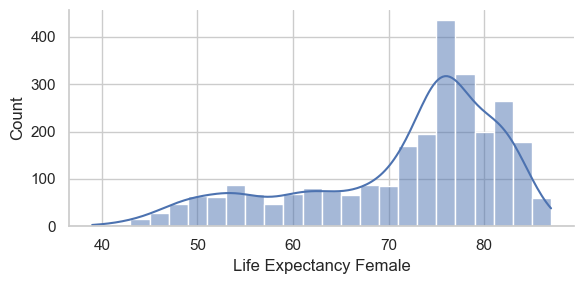

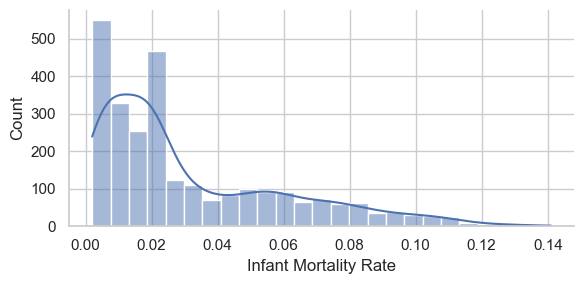

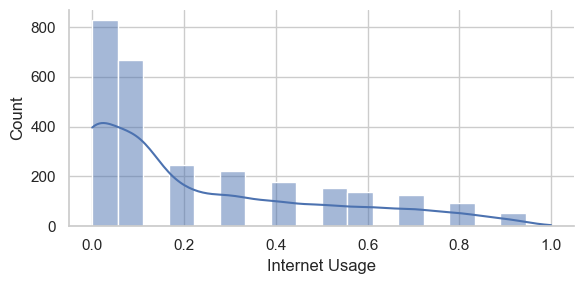

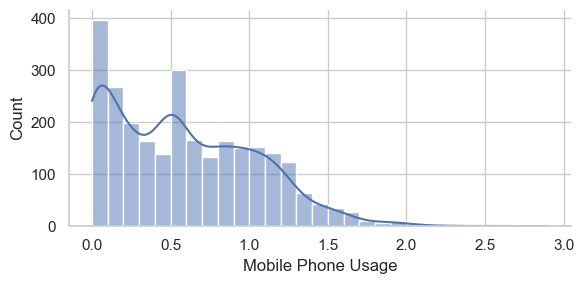

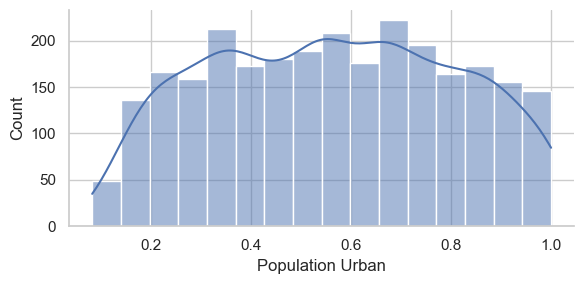

In [19]:
#mid_cols columns are more stable and bounded distributions
#Univariate Analysis
mid_cols = ['Life Expectancy Male','Life Expectancy Female',
            'Infant Mortality Rate','Internet Usage',
            'Mobile Phone Usage','Population Urban']
for col in mid_cols:
    sns.displot(df,x=df[col],
                kde=True,
                kind='hist',
                height=3,
                aspect=2
               )
    plt.show()

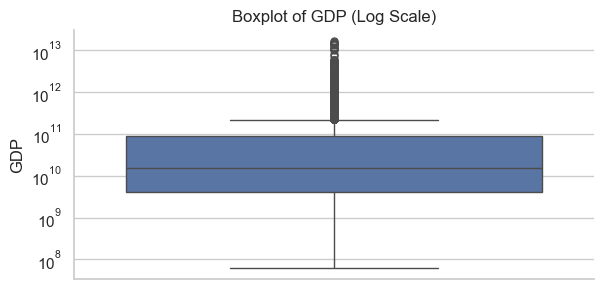

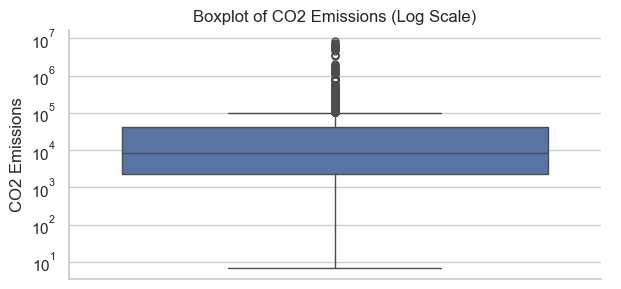

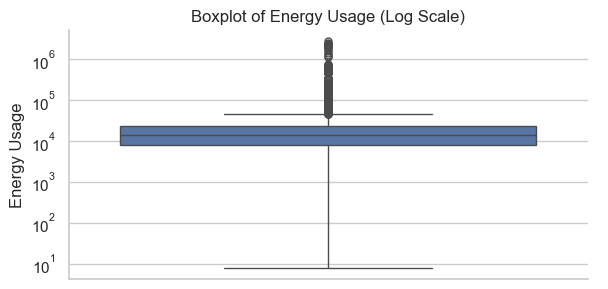

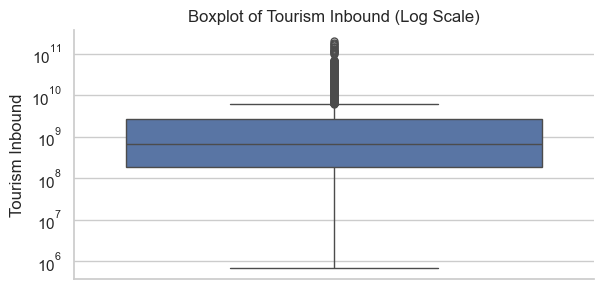

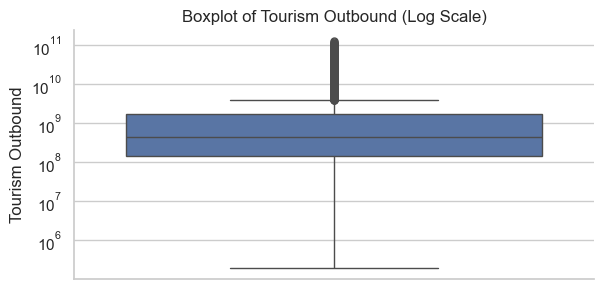

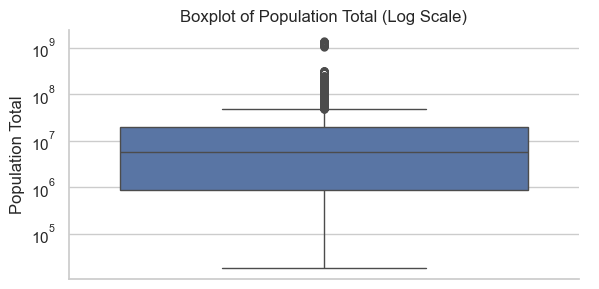

In [20]:
#Columns that have outlies
big_cols = ['GDP','CO2 Emissions','Energy Usage',
            'Tourism Inbound','Tourism Outbound','Population Total']
# Boxplots - Log scale added to see the IQR
for col in big_cols:
    g = sns.catplot(data=df, y=col, # Simplified syntax
                kind='box', 
                height=3, 
                aspect=2)
    g.set(yscale="log") # This allows you to see the box AND the outliers
    plt.title(f"Boxplot of {col} (Log Scale)")
    plt.show()

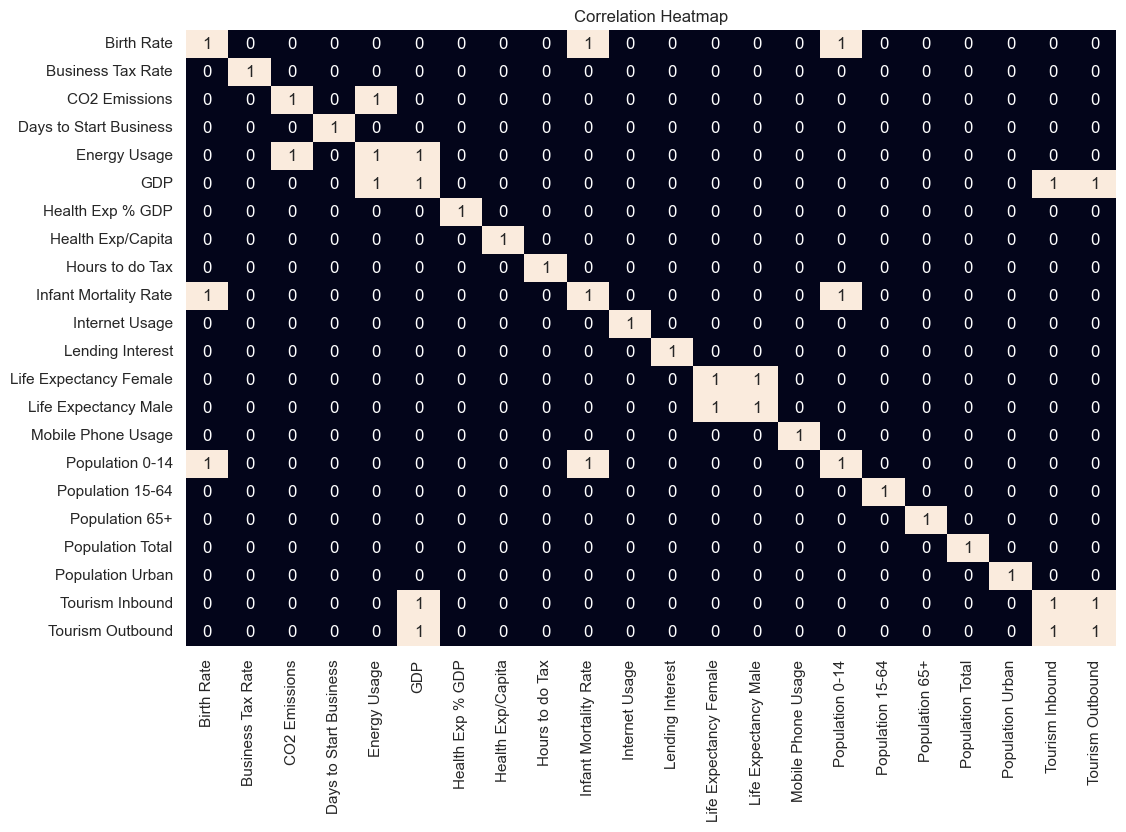

In [21]:
# Correlation Heatmap (Numeric Only)
numeric_df = df.select_dtypes(include=[np.number])  # keep only numeric columns

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr()>0.8, annot=True,cbar=False)
plt.title('Correlation Heatmap')
plt.show()

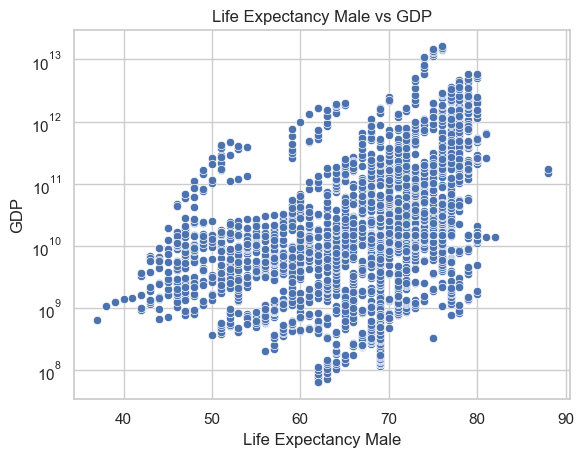

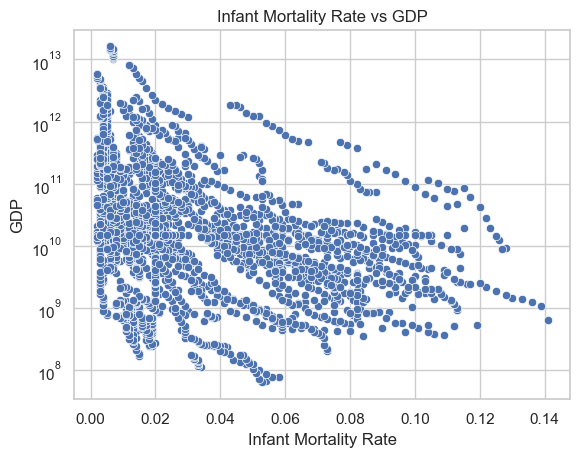

In [22]:
#Bivariate Analysis
pairs=[
    ('Life Expectancy Male','GDP'),
    ('Infant Mortality Rate','GDP')]
for x,y in pairs:
    sns.scatterplot(data=df,x=df[x],y=df[y])
    plt.yscale('log')
    plt.title(f'{x} vs {y}')
    plt.show()

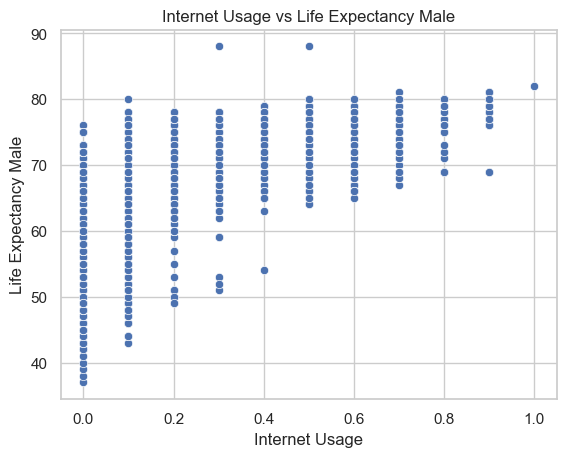

In [23]:
pairs = [
    ('Internet Usage','Life Expectancy Male')]

for x, y in pairs:
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f'{x} vs {y}')
    plt.show()


In [24]:
#Check and count outliers in each column and apply threshold 
num_cols = df.select_dtypes(include='number').columns
Q1=df[num_cols].quantile(0.25)
Q3=df[num_cols].quantile(0.75)
IQR=Q3-Q1
outliers=((df[num_cols]<(Q1-1.5 *IQR))|(df[num_cols]>(Q3+1.5 * IQR))).sum()
percentage=(outliers/len(df))*100
outlier_summary=pd.DataFrame({
    'Count':outliers,
    'Percentage':round(percentage,2)
})
threshold=5
print(outlier_summary[outlier_summary['Percentage']>threshold])

                        Count  Percentage
Business Tax Rate        1130       41.79
CO2 Emissions             387       14.31
Days to Start Business    340       12.57
Energy Usage              424       15.68
GDP                       414       15.31
Health Exp/Capita         412       15.24
Hours to do Tax           980       36.24
Lending Interest          245        9.06
Population Total          318       11.76
Tourism Inbound           409       15.13
Tourism Outbound          461       17.05


In [25]:
#Using log transform to reduce the impact of outliers by keep real meaning of large values
out_cols=['Hours to do Tax','Tourism Outbound','Energy Usage','GDP','Health Exp/Capita','Tourism Inbound','CO2 Emissions','Days to Start Business','Population Total',
          'Lending Interest']
for col in out_cols:
    df[col]=np.log1p(df[col])

In [26]:
#Drop the object column country to standardize the data
df.drop('Country',axis=1,inplace=True)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Scaled_data=scaler.fit_transform(df)
Scaled_data

array([[-0.23386408, -0.13992085,  1.0118155 , ...,  0.14744887,
        -0.86880471, -0.45265326],
       [ 2.46933546, -0.13992085,  0.02510825, ..., -0.97652967,
        -1.38250677, -0.58546019],
       [ 1.8385889 , -0.13992085, -0.76337443, ..., -0.73538518,
        -1.00027626, -1.09539249],
       ...,
       [-0.68439734, -0.10988518, -0.02475173, ...,  1.57387983,
         0.57193445,  0.34332168],
       [-0.23386408,  0.55757415, -0.02475173, ...,  1.33273534,
         0.15141346,  0.88398403],
       [-1.04482395, -0.13992085, -0.02475173, ...,  1.57796703,
         0.02408165, -0.04350074]], shape=(2704, 22))

In [28]:
df

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,41.0,11.384319,3.295837,10.203555,24.726775,0.035,4.110874,5.480639,0.034,0.0,0.095310,71.0,67.0,0.0,0.3420,0.6190,0.039,17.272441,0.599,18.440483,19.078201
1,0.050,41.0,9.163563,3.295837,8.922658,22.934787,0.034,3.135494,5.480639,0.128,0.0,0.709021,47.0,44.0,0.0,0.4760,0.4990,0.025,16.449191,0.324,17.341871,18.799117
2,0.043,41.0,7.388946,3.295837,7.592870,21.581555,0.043,2.772589,5.480639,0.090,0.0,0.113329,57.0,53.0,0.0,0.4540,0.5170,0.029,15.754161,0.383,18.159316,17.727534
3,0.027,41.0,8.361007,3.295837,7.515889,22.479106,0.047,5.030438,5.480639,0.054,0.0,0.144100,52.0,49.0,0.1,0.3830,0.5870,0.029,14.378194,0.532,19.240461,19.157845
4,0.046,41.0,6.948897,3.295837,9.570738,21.682983,0.051,2.564949,5.480639,0.096,0.0,0.113329,52.0,49.0,0.0,0.4680,0.5050,0.028,16.267200,0.178,16.951005,17.216708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.020,41.0,9.051345,3.295837,9.570738,23.436619,0.061,5.267858,5.480639,0.020,0.1,0.113329,75.0,69.0,0.5,0.2995,0.6425,0.052,10.386778,0.911,20.350026,19.938003
2700,0.013,46.4,9.051345,1.791759,14.572781,30.418782,0.179,9.093357,5.170484,0.006,0.8,0.032467,81.0,76.0,1.0,0.1960,0.6670,0.136,19.564501,0.811,26.022043,25.564085
2701,0.015,41.9,9.051345,2.079442,9.570738,24.635376,0.089,7.177019,5.739793,0.010,0.5,0.106160,80.0,74.0,1.5,0.2200,0.6390,0.140,15.037889,0.948,21.521674,20.750881
2702,0.020,61.9,9.051345,4.976734,9.570738,26.666816,0.046,6.386879,6.675823,0.013,0.5,0.151862,78.0,72.0,1.0,0.2880,0.6520,0.060,17.215200,0.889,20.622340,21.887041


In [29]:
#Save Cleaned Data
df.to_csv("Global_development_cleaned.csv", index=False)
print("Cleaned data saved to Global_development_cleaned.csv")

Cleaned data saved to Global_development_cleaned.csv


### Model Building

In [30]:
#Loading the Cleaned data which is ready for model building
data=pd.read_csv('Global_development_cleaned.csv')
data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,41.0,11.384319,3.295837,10.203555,24.726775,0.035,4.110874,5.480639,0.034,0.0,0.095310,71.0,67.0,0.0,0.342,0.619,0.039,17.272441,0.599,18.440483,19.078201
1,0.050,41.0,9.163563,3.295837,8.922658,22.934787,0.034,3.135494,5.480639,0.128,0.0,0.709021,47.0,44.0,0.0,0.476,0.499,0.025,16.449191,0.324,17.341871,18.799117
2,0.043,41.0,7.388946,3.295837,7.592870,21.581555,0.043,2.772589,5.480639,0.090,0.0,0.113329,57.0,53.0,0.0,0.454,0.517,0.029,15.754161,0.383,18.159316,17.727534
3,0.027,41.0,8.361007,3.295837,7.515889,22.479106,0.047,5.030438,5.480639,0.054,0.0,0.144100,52.0,49.0,0.1,0.383,0.587,0.029,14.378194,0.532,19.240461,19.157845
4,0.046,41.0,6.948897,3.295837,9.570738,21.682983,0.051,2.564949,5.480639,0.096,0.0,0.113329,52.0,49.0,0.0,0.468,0.505,0.028,16.267200,0.178,16.951005,17.216708


In [31]:
#Columns of the cleaned data
data.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [32]:
#Columns info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2704 non-null   float64
 1   Business Tax Rate       2704 non-null   float64
 2   CO2 Emissions           2704 non-null   float64
 3   Days to Start Business  2704 non-null   float64
 4   Energy Usage            2704 non-null   float64
 5   GDP                     2704 non-null   float64
 6   Health Exp % GDP        2704 non-null   float64
 7   Health Exp/Capita       2704 non-null   float64
 8   Hours to do Tax         2704 non-null   float64
 9   Infant Mortality Rate   2704 non-null   float64
 10  Internet Usage          2704 non-null   float64
 11  Lending Interest        2704 non-null   float64
 12  Life Expectancy Female  2704 non-null   float64
 13  Life Expectancy Male    2704 non-null   float64
 14  Mobile Phone Usage      2704 non-null   

In [33]:
#importing the unsupervised clustering models and evaluation metrics
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [34]:
# To tune k-means clustering points
wcss=[]
silhouette_scores=[]
k_range=range(2,21)

for i in range(2,21):
    kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=500,random_state=42)
    kmeans.fit(Scaled_data)
    wcss.append(kmeans.inertia_)
    sil_score=silhouette_score(Scaled_data,kmeans.labels_)
    silhouette_scores.append(sil_score)

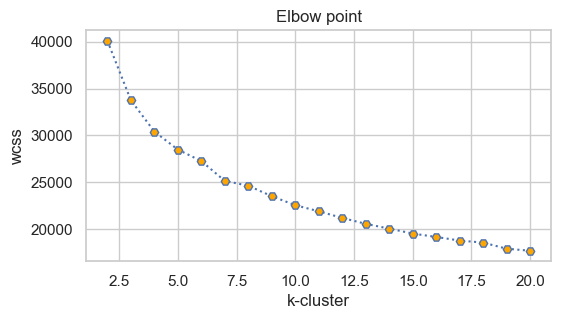

In [35]:
# By ploting Wcss vs k-cluster points we can decide how many clustering points to consider
plt.figure(figsize=(6,3))
plt.plot(k_range,wcss,
         marker='H',markerfacecolor='orange',
         linestyle='dotted'
        )
plt.title('Elbow point')
plt.xlabel('k-cluster')
plt.ylabel('wcss')
plt.show()

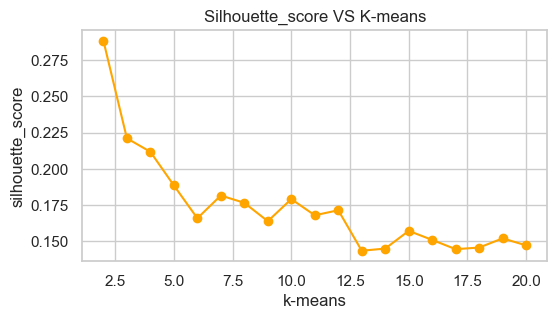

In [36]:
#By ploting we can see the Silhouette_score raising and dropping according k_means values
plt.figure(figsize=(6,3))
plt.plot(k_range,silhouette_scores,marker='o',
         color='orange')
plt.title('Silhouette_score VS K-means')
plt.ylabel('silhouette_score')
plt.xlabel('k-means')
plt.show()

In [37]:
# Taking k-means value as 3 
k_best=3
kmeans=KMeans(n_clusters=k_best,
              init='k-means++',
              max_iter=500,
              random_state=42)
segments=kmeans.fit_predict(Scaled_data)
df['K-means clustering']=segments
segments

array([0, 2, 2, ..., 1, 0, 0], shape=(2704,), dtype=int32)

In [38]:
# Silhouette_score according to this we can say how well the clustering performed by model
sil_kmeans=silhouette_score(Scaled_data,segments)
sil_kmeans

0.22107913807990004

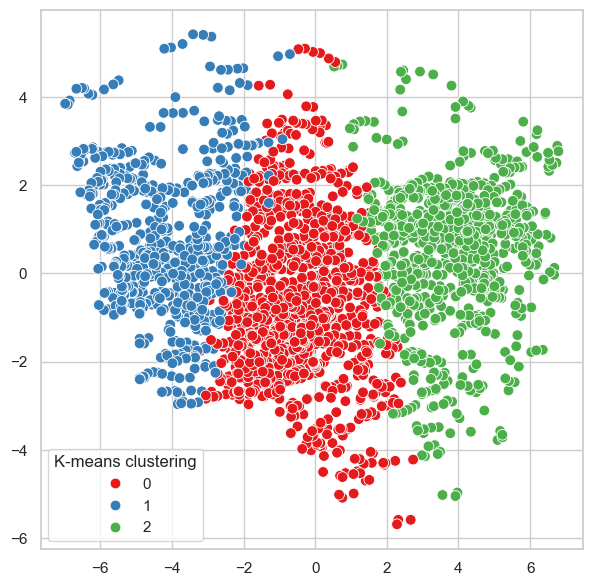

In [39]:
#ploting the clusters made by K_means model on given data
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(Scaled_data)
plt.figure(figsize=(7,7))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=df['K-means clustering'],palette='Set1',s=60)
plt.show()

In [40]:
#To find epsilon value
from sklearn.neighbors import NearestNeighbors
min_points=5

In [41]:
neighbors=NearestNeighbors(n_neighbors=min_points)
neighbors_fit=neighbors.fit(Scaled_data)
distance,indices=neighbors_fit.kneighbors(Scaled_data)
k_distance=np.sort(distance[:,min_points-1])
k_distance

array([7.50430768e-03, 1.03158725e-02, 1.09327513e-02, ...,
       7.41231958e+00, 8.69022713e+00, 1.38741914e+01], shape=(2704,))

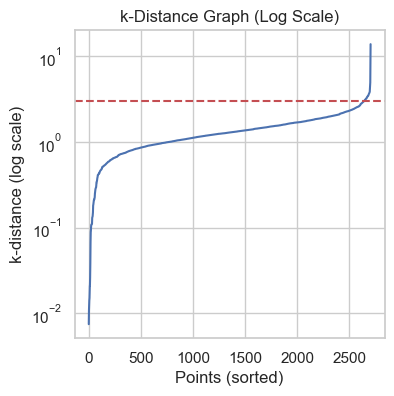

In [42]:
#ploting the graph to consider the epsilon value
plt.figure(figsize=(4,4))
plt.plot(k_distance)
plt.yscale("log")
plt.xlabel("Points (sorted)")
plt.ylabel("k-distance (log scale)")
plt.axhline(y=3, color='r', linestyle='--')
plt.title("k-Distance Graph (Log Scale)")
plt.show()

In [43]:
#From above graph the sudden hike in graph shows epsilon points range between 2.1 to 3.0, so taking 2.4 
dbmodel=DBSCAN(eps=3,min_samples=5,metric='euclidean')
clusters=dbmodel.fit_predict(Scaled_data)
df['DBSCAN clustering']=clusters
np.unique(clusters,return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([  35, 2597,    6,    7,    5,    6,    6,    8,    8,    5,    8,
           8,    5]))

In [44]:
#Calculating the number of clusters
label=dbmodel.labels_
n_clusters=len(set(label))-(1 if -1 in label else 0)
print('No of clusters:',n_clusters)

No of clusters: 12


In [45]:
#Calculating the silhouette score by excluding noise -1
mask = label != -1
sil_DBSCAN=0

if len(set(label[mask])) > 1:
    sil_DBSCAN=(silhouette_score(Scaled_data[mask], label[mask]))
    print("Silhouette:", silhouette_score(Scaled_data[mask], label[mask]))
else:
    print("Silhouette not valid")

Silhouette: 0.06774638113515484


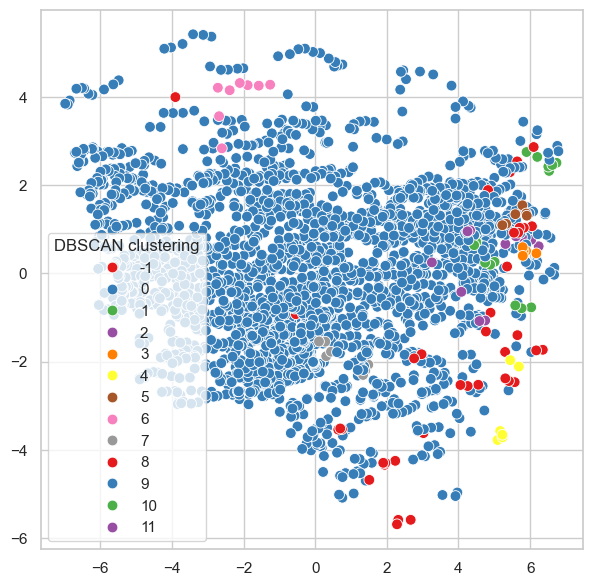

In [46]:
#ploting clusters made by DBSCAN model 
plt.figure(figsize=(7,7))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=df['DBSCAN clustering'],palette='Set1',s=60)
plt.show()

In [47]:
#Impoting hierarchical libraries
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

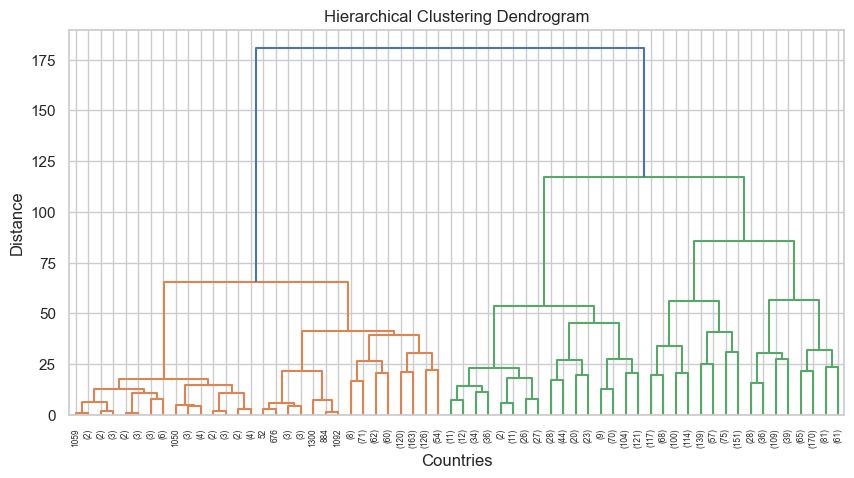

In [48]:
# Plot dendrogram
linked = linkage(Scaled_data, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.show()

In [49]:
# Perform hierarchical clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3,     # same as KMeans
    linkage='ward'    # best for numeric, Euclidean distance
)

df['Hierarchical_Cluster'] = hierarchical.fit_predict(Scaled_data)

In [50]:
#Total value counts of each cluster
df['Hierarchical_Cluster'].value_counts()

Hierarchical_Cluster
0    1410
1     716
2     578
Name: count, dtype: int64

In [51]:
#To analysis average feature values of clusters 
hierarchical=(df.groupby('Hierarchical_Cluster').mean())
hierarchical

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,K-means clustering,DBSCAN clustering
Hierarchical_Cluster,,,,,,,,,,,,,,,,,,,,,,,,
0,0.018943,42.470922,9.152931,3.314622,9.445473,23.310430,0.060581,5.250558,5.547429,0.021844,0.199220,0.127873,74.782270,69.031915,0.552695,0.284846,0.644237,0.069988,14.673840,0.575265,20.239682,19.720773,0.330496,0.020567
1,0.037757,55.566061,7.761777,3.631299,8.904111,22.382767,0.059122,3.705502,5.585382,0.071147,0.031285,0.162253,56.673184,54.248603,0.252793,0.429323,0.538725,0.031933,15.853879,0.347244,18.638564,18.748125,1.924581,0.526536
2,0.012725,38.982007,10.661601,2.819915,10.328515,25.957486,0.077483,7.447655,5.148255,0.006322,0.555017,0.078496,81.169550,75.918685,1.020588,0.189691,0.685080,0.125223,15.745355,0.799995,22.498350,22.369543,0.854671,-0.001730


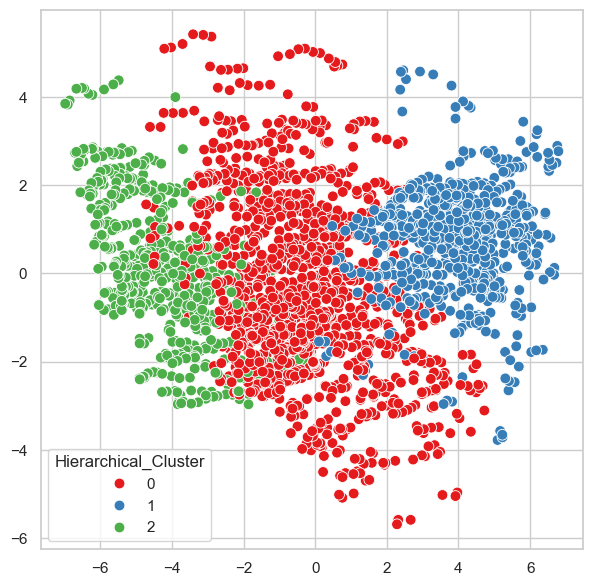

In [52]:
#ploting clusters made by Hierarchical model 
plt.figure(figsize=(7,7))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=df['Hierarchical_Cluster'],palette='Set1',s=60)
plt.show()

In [53]:
#silhouette_score of hierarchical model
sil_hierarchical=silhouette_score(Scaled_data,df['Hierarchical_Cluster'])
sil_hierarchical

0.1866224718185003

In [54]:
# #Results of silhouette_scores of all three models to compare and get best model
# results = {}
# results['KMeans'] = sil_kmeans
# results['DBSCAN'] = sil_DBSCAN
# results['Hierarchical'] =sil_hierarchical

# best_model = max(results, key=results.get)
# print("Silhouette Scores:", results)
# print(f" ********** Best model for deployment: {best_model} ***********")

In [55]:
# #Model comparsion to pick best one for model deployment
# plt.figure(figsize=(7, 5))
# sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Set2")
# plt.ylabel("Silhouette Score")
# plt.title("Model Comparison - Clustering Quality")
# plt.show()

In [56]:
# PCA for visualization (2D)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(Scaled_data)


In [57]:
# Gaussian Mixture Model

In [58]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(Scaled_data)

df['GMM clustering'] = gmm_labels


In [59]:
sil_gmm = silhouette_score(Scaled_data, gmm_labels)
sil_gmm


0.1278180992749737

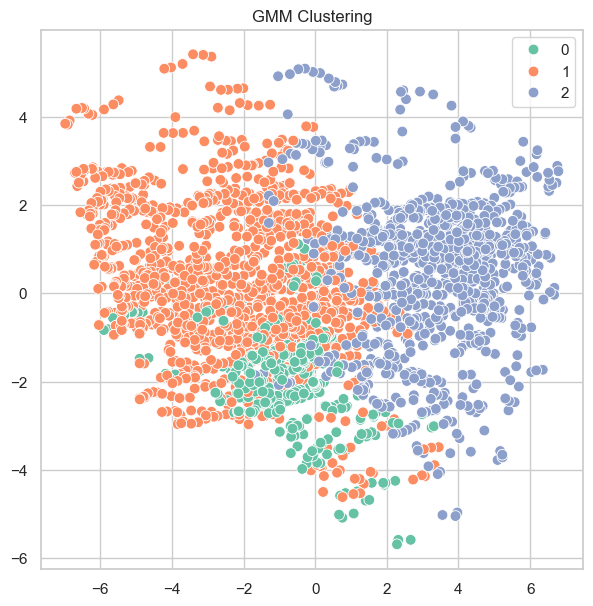

In [60]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=x_pca[:,0],
    y=x_pca[:,1],
    hue=gmm_labels,
    palette='Set2',
    s=60
)
plt.title("GMM Clustering")
plt.show()


In [61]:
# HDBSCAN

In [62]:
%pip install --upgrade hdbscan


Note: you may need to restart the kernel to use updated packages.


In [63]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=10)
hdb_labels = hdb.fit_predict(Scaled_data)
df['HDBSCAN clustering'] = hdb_labels


In [64]:
import pkg_resources
pkg_resources.get_distribution("hdbscan").version


'0.8.42'

In [65]:
mask = hdb_labels != -1

if len(set(hdb_labels[mask])) > 1:
    sil_hdb = silhouette_score(Scaled_data[mask], hdb_labels[mask])
else:
    sil_hdb = np.nan

sil_hdb


-0.0020013709012146196

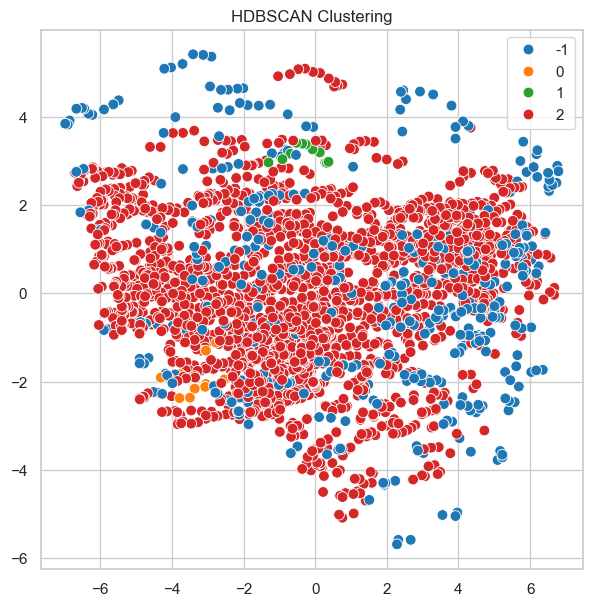

In [66]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=x_pca[:,0],
    y=x_pca[:,1],
    hue=hdb_labels,
    palette='tab10',
    s=60
)
plt.title("HDBSCAN Clustering")
plt.show()


In [67]:
# Grid-Based Clustering

In [68]:
# Use PCA space for grid simplicity
X = x_pca

# define grid size
grid_size = 0.5

# create grid coordinates
x_bin = np.floor(X[:,0] / grid_size)
y_bin = np.floor(X[:,1] / grid_size)

grid_labels = x_bin.astype(int)*1000 + y_bin.astype(int)
df['Grid clustering'] = grid_labels


In [69]:
# remove sparse grids
grid_counts = pd.Series(grid_labels).value_counts()
valid_grids = grid_counts[grid_counts >= 10].index

grid_final = np.array([
    lbl if lbl in valid_grids else -1 for lbl in grid_labels
])

df['Grid clustering'] = grid_final


In [70]:
mask = grid_final != -1

if len(set(grid_final[mask])) > 1:
    sil_grid = silhouette_score(X[mask], grid_final[mask])
else:
    sil_grid = np.nan

sil_grid


0.3548485980160133

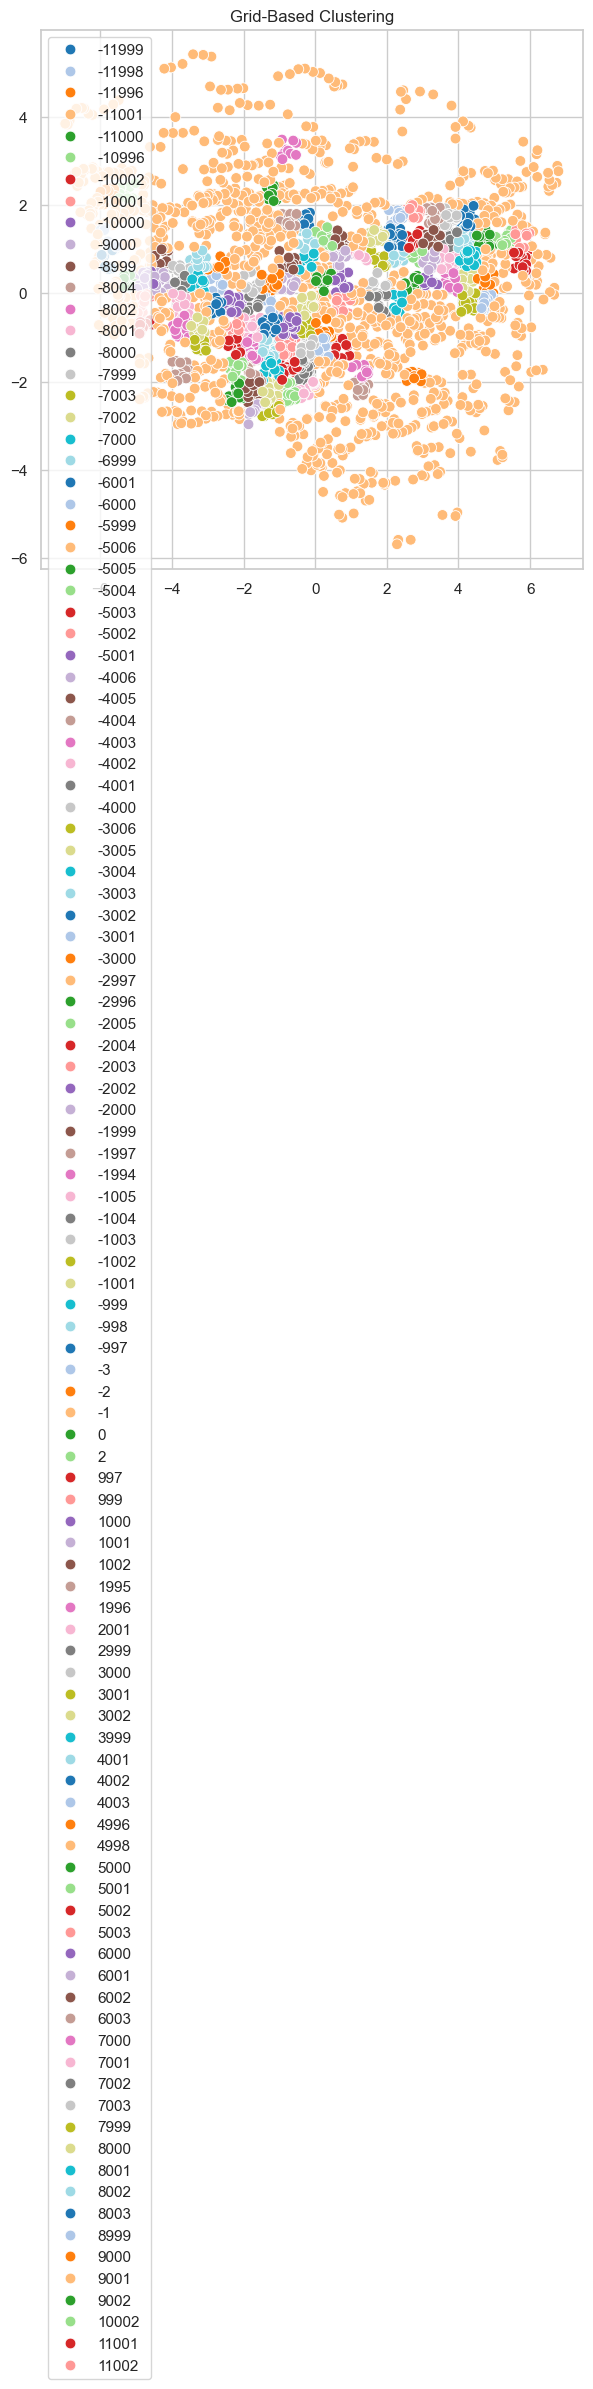

In [71]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=grid_final,
    palette='tab20',
    s=60
)

plt.title("Grid-Based Clustering")
plt.show()

In [72]:
comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical",
        "DBSCAN",
        "GMM",
        "HDBSCAN",
        "Grid-Based"
    ],
    "Silhouette Score": [
        sil_kmeans,
        sil_hierarchical,
        sil_DBSCAN,
        sil_gmm,
        sil_hdb,
        sil_grid
    ]
})

comparison


,Model,Silhouette Score
0,K-Means,0.221079
1,Hierarchical,0.186622
2,DBSCAN,0.067746
3,GMM,0.127818
4,HDBSCAN,-0.002001
5,Grid-Based,0.354849


In [73]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# LOAD DATA
df = pd.read_excel(r'World_development_mesurement.xlsx')

# REMOVE SPECIAL CHARACTERS
cols = ['Business Tax Rate','GDP','Health Exp/Capita',
        'Tourism Inbound','Tourism Outbound']

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$','',regex=False)
        .str.replace('%','',regex=False)
        .str.replace(',','',regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
# DROP HIGH MISSING COLUMN
df.drop('Ease of Business', axis=1, inplace=True)

# DROP IRRELEVANT COLUMN
df.drop('Number of Records', axis=1, inplace=True)

# DROP COUNTRY (NON-NUMERIC)
df.drop('Country', axis=1, inplace=True)

# IMPUTER (MEDIAN)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

# LOG TRANSFORMATION (OUTLIER REDUCTION)
out_cols = ['Business Tax Rate','Hours to do Tax','Tourism Outbound',
            'Energy Usage','GDP','Health Exp/Capita',
            'Tourism Inbound','CO2 Emissions',
            'Days to Start Business','Population Total',
            'Lending Interest']

for col in out_cols:
    df_imputed[col] = np.log1p(df_imputed[col])

# SAVE FEATURE NAMES
features = df_imputed.columns.tolist()

# SCALER
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)

# CREATE MODEL DIRECTORY
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

# SAVE PICKLE FILES
with open(os.path.join(MODEL_DIR, "imputer.pkl"), "wb") as f:
    pickle.dump(imputer, f)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "features.pkl"), "wb") as f:
    pickle.dump(features, f)

# Save the model
with open(os.path.join(MODEL_DIR, "final_model.pkl"), "wb") as f:
    pickle.dump(kmeans, f)

# Also save your PCA object
with open(os.path.join(MODEL_DIR, "pca.pkl"), "wb") as f:
    pickle.dump(pca, f)


print("imputer.pkl saved")
print("scaler.pkl saved")
print("features.pkl saved")
print("final_model.pkl saved")
print("pca.pkl saved")
 

imputer.pkl saved
scaler.pkl saved
features.pkl saved
final_model.pkl saved
pca.pkl saved


In [74]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
